# Data Ingestion & The SpatialExperiment Object (Visium HD)

## Introduction

Throughout this course, we will analyze a human colorectal cancer (CRC) dataset from [Oliveira _et al._ (2025)](https://doi.org/10.1038/s41588-025-02193-3). While the original study contains multiple patients, we will focus specifically on Patient 2 ("P2"), whose data is publicly available via the [10x Genomics website](https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-human-crc). For this sample, the study provides both Visium HD data and matching Xenium In Situ data generated from a serial tissue section, allowing for excellent cross-platform comparisons later in the course.

### Learning objectives

- Import 10x Visium HD Space Ranger binned outputs directly into R.
- Understand the internal structure and modularity of the `SpatialExperiment` (SPE) class.
- Access and interpret physical tissue coordinates (`spatialCoords`) and histological image metadata (`imgData`).
- Extract and inspect gene expression counts (`assay`), as well as observation and feature annotations (`colData` / `rowData`).
- Perform spatial and logical subsetting operations to isolate specific tissue regions of interest.
- Render Visium HD transcriptomic data seamlessly mapped over the underlying H&E tissue image.

### Course dataset

#### Understanding the Visium HD data

Recall that RNA measurements in Visium HD are indirect: targeted probe pairs are hybridized to the RNA, ligated, captured on the slide, and then sequenced. Space Ranger outputs then aggregate these captured molecules over _square spatial areas_.

While the smallest physical capture squares on a Visium HD slide are 2x2µm, larger bins are created by computationally pooling neighboring squares. Here, we will focus specifically on the **16µm binned output** (which aggregates 64 smaller 2µm bins).

**The Resolution Tradeoff:** Binning increases the number of UMIs per gene and per bin, drastically reducing the sparsity of the data. For this course, 16µm bins are a highly practical compromise: _they make the dataset small enough to compute quickly while still preserving tissue-level spatial structure._ However, this comes at the biological cost of true single-cell resolution, as a 16µm bin will almost certainly capture RNA from multiple overlapping cells.

Because the full whole-slide output is massive even at 16µm, we will be working with a pre-selected Region of Interest (ROI). This compact region was chosen because it captures rich morphological diversity, including both dense, gland-like epithelial structures and lower-density stromal areas.

#### Initial Quality Control

The **Space Ranger web summary** (`Visium_HD_Human_Colon_Cancer_P2_web_summary.html`) and the metrics summary CSV are the standard reports used for this. They provide an immediate overview of crucial metrics such as sequencing saturation, probe mapping rates, and the total number of bins detected under the tissue.

We have explicitly included these reports in our prepared data package! We can find them inside the `data/Human_Colon_Cancer_P2/reports/` directory. If we open the HTML file in our web browser, we will see an interactive dashboard allowing us to explore these global metrics and tissue overlays before writing any code:

1. Looking at the **Mapping** section, here, *95.1% of reads mapped confidently to the filtered probe set*. This is an exceptionally high score, confirming that the biochemical hybridization step worked perfectly and the probes attached to real, expected RNA targets without excessive off-target noise.
2. Looking at the **Sequencing** section, the *Sequencing Saturation is 56.4%*. This means we have sequenced slightly over half of the unique molecules physically available in the library. While higher is always better, >50% is generally considered sufficient for complex spatial datasets.
3. The interactive map on the right plots the total UMI counts over the physical H&E image. We should verify that high UMI counts (warm colors like red/yellow) perfectly trace dense cellular structures like the colonic glands, while low counts (blue) correspond to sparse stromal areas or empty space.

In [1]:
# Define the explicit path to the metrics CSV
metrics_file <- "data/Human_Colon_Cancer_P2/reports/Visium_HD_Human_Colon_Cancer_P2_metrics_summary.csv"

# Read the CSV (we use check.names=FALSE to preserve the spaces in the 10x column names)
visium_metrics <- read.csv(metrics_file, check.names = FALSE)

# Transpose the data frame for easier reading in the notebook
visium_metrics_t <- as.data.frame(t(visium_metrics))
colnames(visium_metrics_t) <- "Value"

# Display the metrics
print(visium_metrics_t)

                                                                              Value
Sample ID                                           Visium_HD_Human_Colon_Cancer_P2
Number of Reads                                                           721219716
Valid Barcodes                                                            0.8949706
Valid UMIs                                                                0.9988197
Sequencing Saturation                                                     0.5650806
Q30 Bases in Barcode                                                      0.9481857
Q30 Bases in Probe Read                                                   0.9413891
Q30 Bases in UMI                                                          0.9516016
Reads Mapped to Probe Set                                                 0.9876445
Reads Mapped Confidently to Probe Set                                     0.9819929
Fraction Reads in Squares Under Tissue                                    0.

This table perfectly illustrates the fundamental tradeoff in spatial transcriptomics:

* **The Computational Cost:** At 8µm, the tissue is covered by **545,913 bins**. Processing a matrix of this size requires significant computational power and RAM. By moving to 16µm, the data footprint shrinks by a factor of 4 (down to 137k bins).
* **The Sparsity Tradeoff:** At 8µm, the average bin only captures ~488 transcript molecules (UMIs). This sparsity makes clustering noisy. By aggregating into 16µm bins, the average transcript depth jumps to **~1,945 UMIs and 1,274 unique genes per bin**. This provides a much richer, robust biological signal that behaves very similarly to high-quality single-cell RNA-seq data.

## Environment setup

### Loading libraries

In [2]:
# Suppress startup messages to keep the notebook output clean
suppressPackageStartupMessages(suppressWarnings({
  # Core Spatial & Single-Cell Infrastructure
  library(HDF5Array)
  library(scuttle)
  library(SpatialExperiment)
  library(VisiumIO)

  # Data Manipulation & Visualization
  library(dplyr)
  library(ggspavis)
  library(patchwork)
}))

### Loading the dataset

Recall that raw 10x Genomics outputs are incredibly massive. During the data preparation phase (["Assembling the Spatial Transcriptomics Datasets"](./00-assembling_spatial_transcriptomics_datasets.ipynb)), we cropped the original whole-slide output down to a highly specific, morphology-rich Region of Interest (ROI) and stripped away unnecessary raw matrices to create a lightweight, optimized course dataset.

This compact dataset is already sitting locally in our `data/Human_Colon_Cancer_P2` directory. The code block below runs a quick sanity check to verify that R can locate these assembled files before we attempt to import them.

In [3]:
# Define the path to our subsetted course dataset
data_dir <- "data"
human_colon_cancer_data_dir <- file.path(data_dir, "Human_Colon_Cancer_P2")

# Sanity check: Ensure the dataset was generated in the previous notebook
if (!dir.exists(human_colon_cancer_data_dir)) {
  stop(
    "Data directory not found! \n",
    "Please ensure we have successfully run the '00-assembling' notebook ",
    "to generate the 'data/Human_Colon_Cancer_P2' folder before proceeding.\n",
    "(Alternatively, uncomment and run the download script below)."
  )
} else {
  message("Dataset found successfully! You are ready to proceed.")
}

Dataset found successfully! You are ready to proceed.



In [4]:
# ==============================================================================
# ALTERNATIVE: Download Pre-packaged Data
# ==============================================================================
# If we skipped the '00-assembling' notebook, we can uncomment the code 
# below to download the pre-assembled course dataset directly from AWS:

# dir.create(data_dir, showWarnings = FALSE)
# options(timeout = 600)
# 
# message("Downloading pre-packaged dataset from AWS...")
# download.file(
#   url = "https://intro-spatial-transcriptomics-training.s3.eu-central-1.amazonaws.com/spatial_course_data.tar.gz",
#   destfile = file.path(data_dir, "spatial_course_data.tar.gz"),
#   mode = "wb"
# )
# 
# message("Extracting dataset...")
# untar(
#   tarfile = file.path(data_dir, "spatial_course_data.tar.gz"),
#   exdir = data_dir
# )
# 
# file.remove(file.path(data_dir, "spatial_course_data.tar.gz"))
# message("Download and extraction complete!")

### Importing into a SpatialExperiment object

Remember that during the previous data preparation phase, we did not save a pre-processed R object (like an `.rds` file). Instead, we packaged the standard 10x Space Ranger output directory containing the filtered `.h5` count matrix and the `spatial/` image folder.

We will now import the 16µm binned Visium HD output directly into a `SpatialExperiment` (SPE) object. We use the `TENxVisiumHD` package, which is specifically designed to parse standard Space Ranger outputs and automatically bind the count matrices to their respective histological images.

In [5]:
# Import data into a SpatialExperiment object
spe <- TENxVisiumHD(
  spacerangerOut = human_colon_cancer_data_dir, 
  processing = "filtered", # explicitly included even if the only remaining matrix
  format = "h5", 
  images = "lowres", 
  bin_size = "016"
) |> import()

Because standard 10x `.h5` files use Ensembl IDs (e.g., `ENSG00000243485`) as their default (row) identifiers, our immediate first step after importing is to convert the object's rownames into human-readable Gene Symbols (e.g., `PIGR`) using the `uniquifyFeatureNames()` function.

In [6]:
head(rownames(spe))

[1] "ENSG00000187634" "ENSG00000188976" "ENSG00000187961" "ENSG00000187583"
[5] "ENSG00000187642" "ENSG00000188290"

In [7]:
# Use unique Gene Symbols for rownames instead of Ensembl IDs
rownames(spe) <- uniquifyFeatureNames(
  ID = rowData(spe)$ID, 
  names = rowData(spe)$Symbol)

In [8]:
# Print the object to see its initial dimensions
spe

class: SpatialExperiment 
dim: 18085 137051 
metadata(2): resouces spatialList
assays(1): counts
rownames(18085): SAMD11 NOC2L ... MT-ND6 MT-CYB
rowData names(3): ID Symbol Type
colnames(137051): s_016um_00052_00082-1 s_016um_00010_00367-1 ...
  s_016um_00037_00193-1 s_016um_00144_00329-1
colData names(6): barcode in_tissue ... bin_size sample_id
reducedDimNames(0):
mainExpName: Gene Expression
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

### Subsetting the ROI

When we check the dimensions of the `spe` object we just imported, we will notice it contains **137,051 bins**. During the dataset preparation phase, we made the `Human_Colon_Cancer_P2` folder lightweight for distribution by discarding giant TIFF images and empty background matrices. However, we deliberately retained the full tissue matrix.

While the *file size* on the hard drive is now small, keeping 137,000+ bins in the laptop's active RAM is still computationally heavy for downstream clustering and spatial statistics. 

Therefore, we need to spatially crop this massive object down to a manageable Region of Interest (ROI, ~22,000 bins). We selected this specific bounding box because it captures a rich morphological mixture of gland-like epithelial structures and stromal areas. 

*(Note: These exact coordinate boundaries were optimized during our previous data assembly phase and are formally documented in the `README.md` file located inside our dataset folder).*

We define these coordinate boundaries below and use standard R matrix subsetting `[rows, columns]` to crop the object. Notice that we specifically subset the columns (bins) based on their physical `spatialCoords()`.

In [9]:
# Define the exact coordinates for our Region of Interest (ROI)
roi_visium <- c(
  xmin = 49000,
  xmax = 58000,
  ymin = 7500,
  ymax = 16000
)

In [10]:
# Subset columns (bins) to strictly those within the ROI bounding box
spe <- spe[, 
  spatialCoords(spe)[, 1] >= roi_visium[["xmin"]] &
  spatialCoords(spe)[, 1] <= roi_visium[["xmax"]] &
  spatialCoords(spe)[, 2] >= roi_visium[["ymin"]] &
  spatialCoords(spe)[, 2] <= roi_visium[["ymax"]]
]

# Print the object to see the newly reduced dimensions
spe

class: SpatialExperiment 
dim: 18085 22419 
metadata(2): resouces spatialList
assays(1): counts
rownames(18085): SAMD11 NOC2L ... MT-ND6 MT-CYB
rowData names(3): ID Symbol Type
colnames(22419): s_016um_00144_00175-1 s_016um_00204_00145-1 ...
  s_016um_00231_00291-1 s_016um_00193_00227-1
colData names(6): barcode in_tissue ... bin_size sample_id
reducedDimNames(0):
mainExpName: Gene Expression
altExpNames(0):
spatialCoords names(2) : pxl_col_in_fullres pxl_row_in_fullres
imgData names(4): sample_id image_id data scaleFactor

## Anatomy of a SpatialExperiment object

The `SpatialExperiment` (SPE) class extends the `SingleCellExperiment` class classically used for scRNA-seq analysis. *(As a refresher on core single-cell object mechanics, check out our related [biology-informed multiomics training course](https://github.com/sbwiecko/biology-informed-multiomics-training/))*. This means it inherits all the familiar single-cell accessors (`colData()`, `rowData()`, `assay()`), while augmenting it with unique spatial-specific slots.

![Overview of the `SpatialExperiment` class structure](../assets/img/spe.png)

### The single-cell foundation (shared with SCE)

#### Observation & feature metadata (`colData` & `rowData`)

In spatial transcriptomics, the "observations" (columns) are the physical 16µm bins. If we inspect the `colData` slot, we will see several highly specific columns automatically generated by the Space Ranger pipeline.

In [11]:
# Inspect the first few rows of bin metadata
# head(colData(spe))
colData(spe) |> head()

DataFrame with 6 rows and 6 columns
                                    barcode in_tissue array_row array_col
                                <character> <integer> <integer> <integer>
s_016um_00144_00175-1 s_016um_00144_00175-1         1       144       175
s_016um_00204_00145-1 s_016um_00204_00145-1         1       204       145
s_016um_00237_00273-1 s_016um_00237_00273-1         1       237       273
s_016um_00191_00159-1 s_016um_00191_00159-1         1       191       159
s_016um_00245_00233-1 s_016um_00245_00233-1         1       245       233
s_016um_00116_00279-1 s_016um_00116_00279-1         1       116       279
                         bin_size   sample_id
                      <character> <character>
s_016um_00144_00175-1         016    sample01
s_016um_00204_00145-1         016    sample01
s_016um_00237_00273-1         016    sample01
s_016um_00191_00159-1         016    sample01
s_016um_00245_00233-1         016    sample01
s_016um_00116_00279-1         016    sample01

* **`barcode_id`**: The unique nucleotide barcode sequence identifying the spatial bin.
* **`sample_id`**: Identifies which tissue sample the bin belongs to (which is crucial when we merge multiple tissue sections later!).
* **`array_row` & `array_col`**: The discrete grid indices of where the bin sits on the physical Visium array capture area. *(Note: these are grid indices, which are different from the continuous pixel coordinates we will see later).*
* **`in_tissue`**: A logical flag (`0` or `1`) indicating whether the bin physically overlaps the biological tissue.

**Question:** Are all the bins in our subset actually covering tissue?

In [12]:
# Check how many bins fall under the tissue vs background
# Convert to a factor with explicit levels 0 and 1 so table() shows empty categories
colData(spe)$in_tissue |> 
  factor(levels = c(0, 1)) |> 
  table()


    0     1 
    0 22419 

Notice that the output is entirely `1` (which stands for `TRUE`). There are no `0`s (background bins) in this object. This is because we explicitly loaded the **filtered** count matrix from Space Ranger, which pre-removes all empty background bins that do not overlap the physical tissue.

The "features" (rows) are our genes. Let's check how they are annotated.

In [13]:
# Inspect the gene metadata
rowData(spe) |> head()

DataFrame with 6 rows and 3 columns
                     ID      Symbol            Type
            <character> <character>        <factor>
SAMD11  ENSG00000187634      SAMD11 Gene Expression
NOC2L   ENSG00000188976       NOC2L Gene Expression
KLHL17  ENSG00000187961      KLHL17 Gene Expression
PLEKHN1 ENSG00000187583     PLEKHN1 Gene Expression
PERM1   ENSG00000187642       PERM1 Gene Expression
HES4    ENSG00000188290        HES4 Gene Expression

#### The count matrix (`assay`)

At the heart of the object is the `assays` slot, which stores the biological data. Importantly, this object is designed to hold *multiple* data matrices (layers) of the exact same dimensions simultaneously.

If we look back at the summary of the `spe` object we printed in the previous step, we may have noticed the line `assays(1): counts`. Right now, our object only contains this single raw counts matrix. Later in the course, when we normalize the data, a second matrix called `"logcounts"` will be added here.

In [14]:
# Print a preview of the actual count matrix
assay(spe, "counts")

<18085 x 22419> sparse DelayedMatrix object of type "integer":
        s_016um_00144_00175-1 ... s_016um_00193_00227-1
 SAMD11                     0   .                     0
  NOC2L                     0   .                     0
 KLHL17                     0   .                     0
PLEKHN1                     0   .                     0
  PERM1                     0   .                     0
    ...                     .   .                     .
MT-ND4L                     1   .                     0
 MT-ND4                     2   .                     8
 MT-ND5                     0   .                     1
 MT-ND6                     0   .                     0
 MT-CYB                     0   .                     2

**Question:** What class is used to store the UMI count matrix? What is special about it?

In [15]:
# Check the specific class of the count matrix
assay(spe) |> class()

[1] "DelayedMatrix"
attr(,"package")
[1] "DelayedArray"

The matrix is stored as a `DelayedMatrix` (specifically an out-of-memory HDF5 array). Because spatial datasets can contain millions of bins, this format allows R to process the data efficiently without loading the entire massive matrix into limited RAM.

#### Reduced dimensions (`reducedDims`)

Another familiar slot is `reducedDims`, designed to store the coordinates of dimensionality reduction algorithms like PCA or UMAP.

In [16]:
# Check the reduced dimensions slot
reducedDims(spe)

List of length 0
names(0): 

Right now, it is completely empty. This makes perfect sense because we have only just imported the raw data. In upcoming notebooks, after we filter and normalize our count matrix, we will run PCA and UMAP and store their coordinates in this exact slot.

### The Spatial extensions (unique to SPE)

We now arrive at the slots that actually make this object "spatial". These are the defining features that distinguish a `SpatialExperiment` from a standard single-cell object.

#### Physical coordinates (`spatialCoords`)

This slot stores the precise $(x,y)$ physical coordinates for every single bin on the tissue array. Notice that in 10x Visium data, these are stored in *pixel* coordinates relative to the full-resolution image.

In [17]:
# Extract the physical (x,y) pixel coordinates of the first 6 bins
spatialCoords(spe) |> head()

,pxl_col_in_fullres,pxl_row_in_fullres
s_016um_00144_00175-1,50935.66,14076.263
s_016um_00204_00145-1,49228.67,10548.476
s_016um_00237_00273-1,56729.41,8718.557
s_016um_00191_00159-1,50036.54,11318.543
s_016um_00245_00233-1,54399.11,8220.724
s_016um_00116_00279-1,56989.11,15791.601


#### Tissue image metadata (`imgData`)

This slot holds the underlying histological H&E tissue image, as well as the crucial mathematical **scale factors** needed to properly align our UMI count matrix with the picture of the tissue.

In [18]:
# Inspect the attached tissue image metadata and scale factors
imgData(spe)

DataFrame with 1 row and 4 columns
    sample_id    image_id   data scaleFactor
  <character> <character> <list>   <numeric>
1    sample01      lowres   ####  0.00797342

#### Visualizing the tissue (`imgRaster`)

Because full-resolution tissue images are massive, Space Ranger automatically generates lower-resolution versions that R can comfortably hold in active memory. 

If we recall the `TENxVisiumHD()` import function we ran at the very beginning of this notebook, we explicitly included the argument `images = "lowres"`. This told R to load this specific, lightweight image into the `imgData` slot. We can extract and plot this underlying tissue image directly from our object using the `imgRaster()` function.

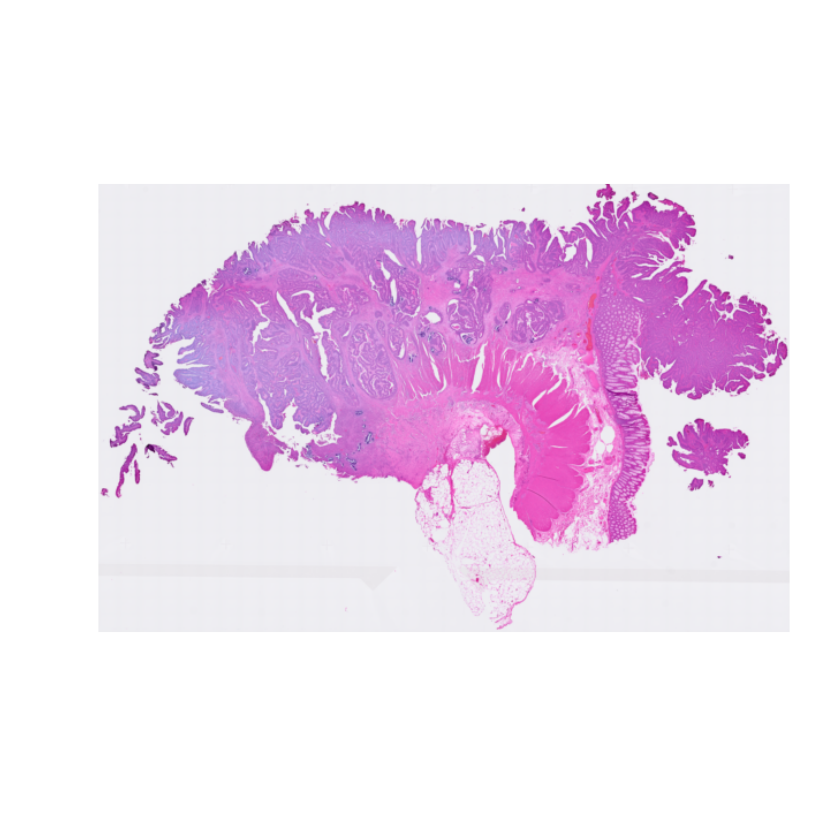

In [19]:
# Extract the tissue image from the object and plot it
imgRaster(spe) |> plot()

## Visualizing the tissue region

Now that we understand the internal architecture of our `SpatialExperiment` object, we can combine all of these slots together to visualize our data.

Now that we understand the internal architecture of our `SpatialExperiment` object, we can combine all of these slots together to visualize our data using the `plotVisium()` function from the `ggspavis` package. We briefly used this function in our [previous data assembly notebook](./00-assembling_spatial_transcriptomics_datasets.ipynb) to visually verify our spatial crop.

### Mapping the array to the tissue

First, let's plot the underlying tissue image by explicitly telling the function to hide the transcriptomic data.

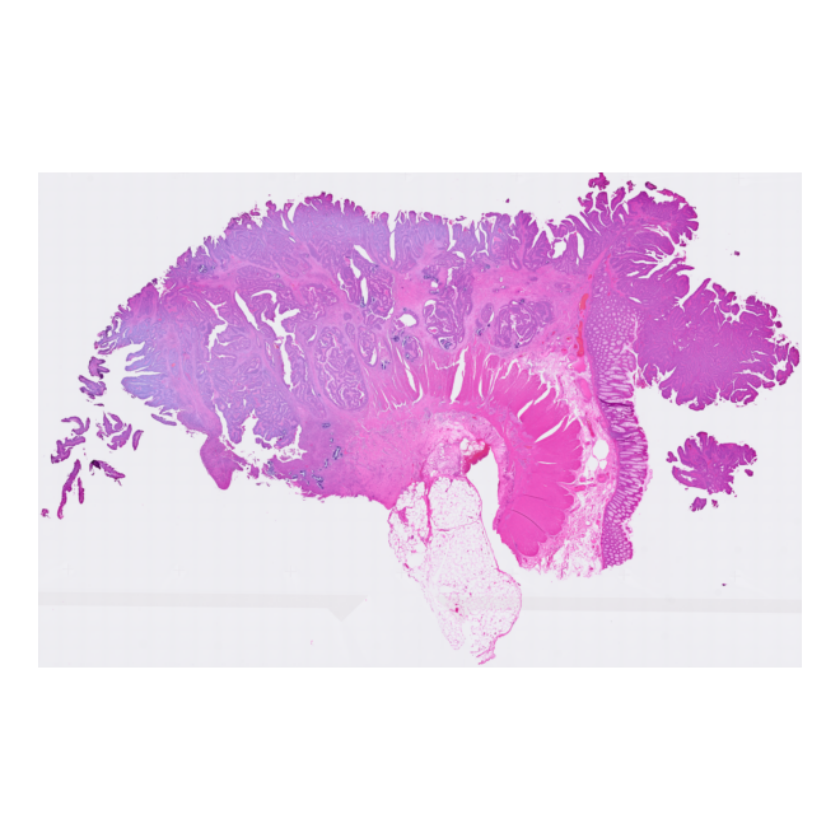

In [20]:
# Plot the aligned tissue image while hiding the transcriptomic bins (spots = FALSE)
plotVisium(spe, spots = FALSE)

While `imgRaster()` simply displays the raw background photograph, `plotVisium()` is a high-level mapping function. It uses the mathematical scale factors stored in `imgData` to align our physical `spatialCoords` precisely over the photograph. This allows us to project our biological data (the 16µm bins) perfectly onto the tissue!

Next, let's overlay our transcriptomic data directly on top of the image. By rendering the 16µm bins, we can see exactly how our data physically aligns with the underlying morphological structures.

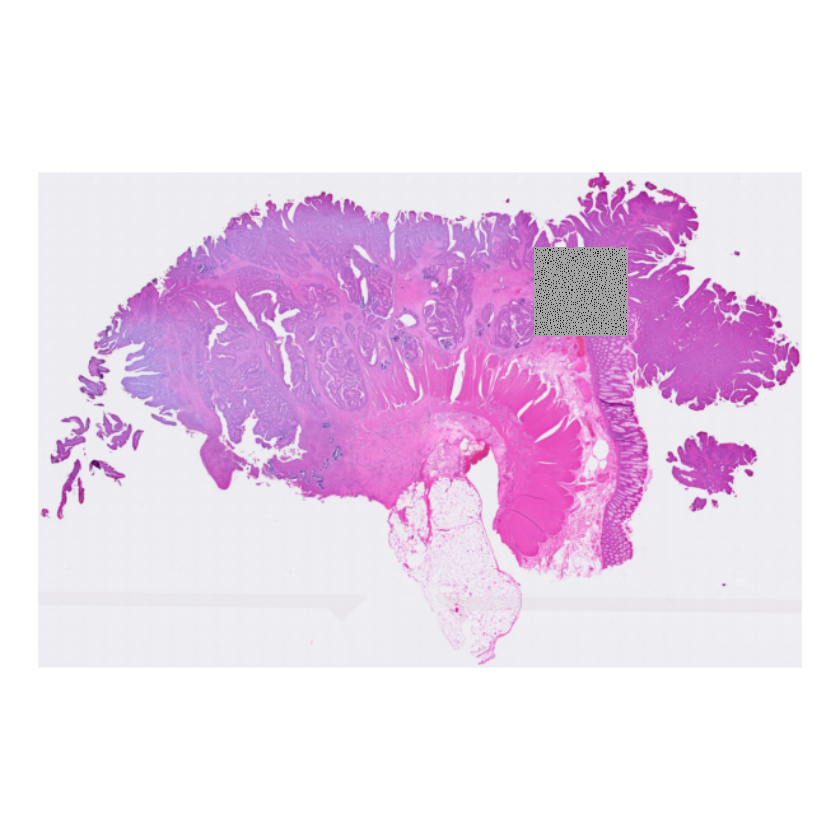

In [21]:
# Overlay the spatial bins on the tissue.
# We use point_shape = 22 (filled squares) to accurately represent Visium HD's square bin geometry,
# and scale them slightly (point_size = 0.5) for better visualization.
plotVisium(spe, point_shape = 22, point_size = 0.5)

### Zooming & gene expression

**Why is the array so small?**

If we look closely at the plot we just generated, we notice that the underlying H&E image shows the **entire** tissue slice, but our transcriptomic bins (the grey squares) only cover a tiny square patch in the top right.

This perfectly illustrates how a `SpatialExperiment` object is architected. Earlier, we subsetted our object using a coordinate bounding box (`spe <- spe[spatialCoords...]`). That operation successfully deleted all the **bins** outside our ROI from the count matrix. However, the `imgData` slot, which holds the background photograph, is completely independent of the count matrix. Subsetting the bins does not automatically crop the underlying background image.

To fix that visual framing, we can add the `zoom = TRUE` argument to our function call.

We can also color the bins according to the expression of a specific gene (like **PIGR**, a known marker for glandular epithelial cells). Recall, we actually generated this exact zoomed-in PIGR plot during the previous dataset preparation notebook to verify that our ROI captured interesting biological structures.

>If we read the `?plotVisium` documentation, it claims the `annotate` argument only looks for columns in `colData`. However, the function is actually smarter, and if it doesn't find the name in `colData`, it automatically searches the object's `rownames` to extract gene expression instead.

Because we ran `uniquifyFeatureNames()` earlier in this notebook, we can conveniently pass the human-readable symbol `"PIGR"` to this argument.

Warning message in guide(title = annotate, order = 1, override.aes = list(col = NA, :
"Arguments in `...` must be used.
✖ Problematic argument:
• override.aes = list(col = NA, size = 3)
ℹ Did you misspell an argument name?"


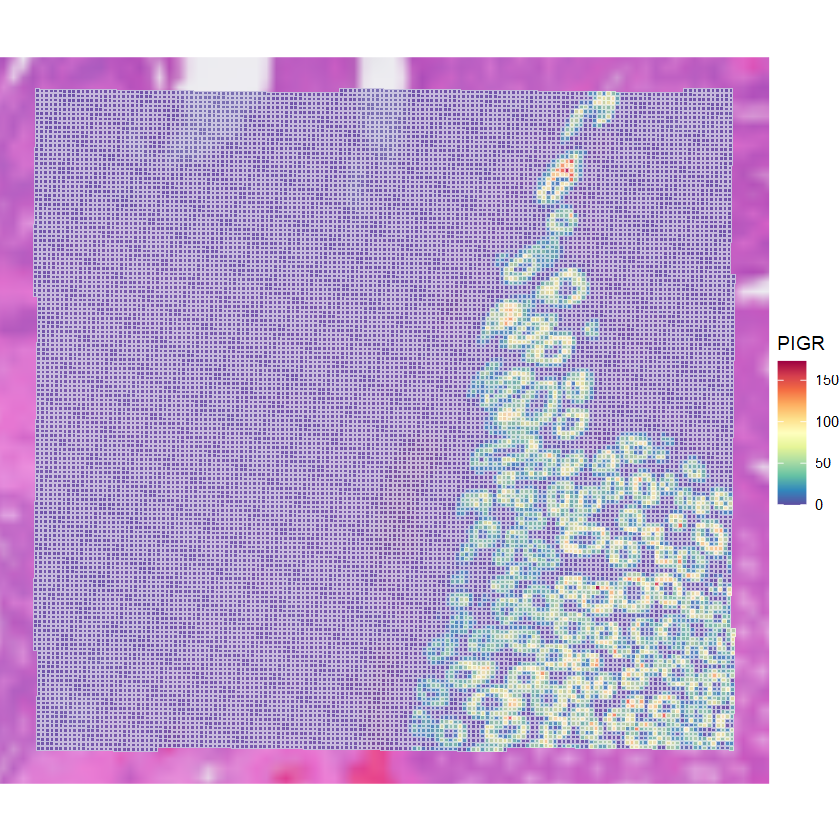

In [22]:
# Plot PIGR expression, zoomed in on our ROI
# (Note: we plot raw "counts" as log-normalization is introduced later)
plotVisium(
  spe, 
  annotate = "PIGR", 
  assay = "counts", 
  zoom = TRUE, 
  point_size = 1, 
  point_shape = 22)

Because we zoomed in, we can now clearly see the individual 16µm square bins spanning our ROI. Moreover, the left side of the tissue (the stroma) is completely dark blue, indicating zero expression of the *PIGR* gene. In stark contrast, the right side of the tissue is packed with distinct, circular glandular structures. The high expression of *PIGR* (the warm yellow and red bins) traces these specific epithelial structures perfectly.

### Visualizing spatial metadata

The `plotVisium()` function is incredibly versatile. We just used it to plot biological gene expression from our count matrix, but we can also use it to color the bins based on any metadata column stored in the `colData` slot. This means we can easily map _non-biological_, technical metadata directly onto our histological images! 

For example, let's color our zoomed-in region using the `array_row` column. Recall from our earlier exploration of the object's metadata that `array_row` stores the discrete, physical row position of each bin on the Visium HD capture grid. Let's see what this looks like when plotted.

Warning message in guide(title = annotate, order = 1, override.aes = list(col = NA, :
"Arguments in `...` must be used.
✖ Problematic argument:
• override.aes = list(col = NA, size = 3)
ℹ Did you misspell an argument name?"


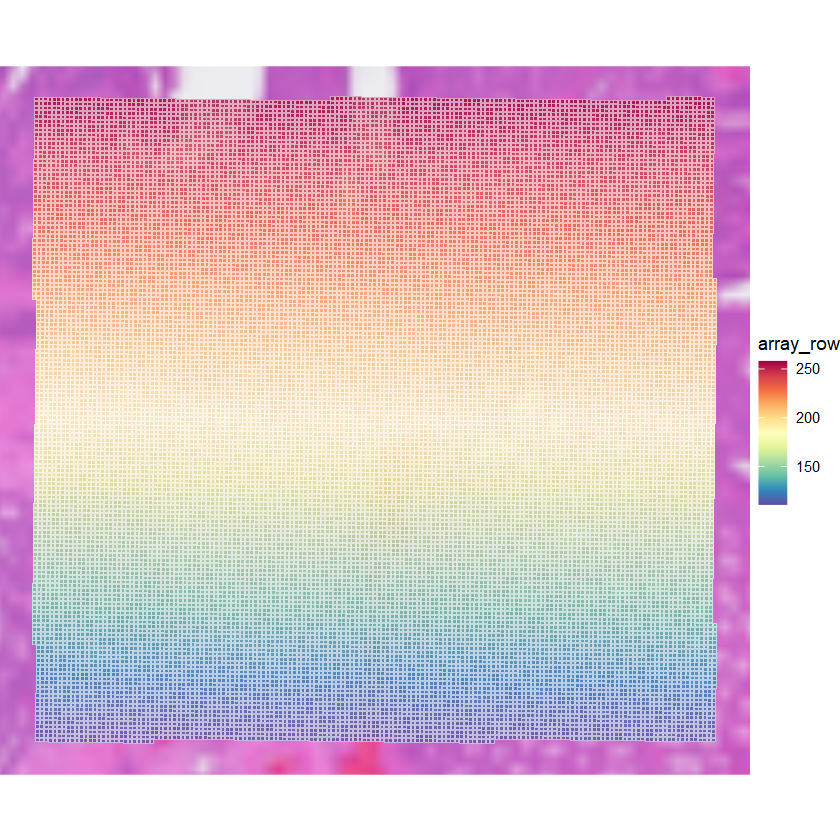

In [23]:
# Color the bins based on their physical row on the Visium array
plotVisium(
  spe, 
  annotate = "array_row", 
  zoom = TRUE, 
  point_shape = 22)

Instead of tracing the structural biology of the tissue, the colors form a perfect, smooth gradient moving vertically from the top of the image down to the bottom (from row ~250 down to row ~125). Because we are plotting technical grid coordinates rather than RNA counts, the color pattern is completely independent of whatever tissue morphology lies beneath it.

## Finalizing the object

### Removing empty bins

In a standard spatial transcriptomics pipeline, the final step before saving the data is to filter out any background bins.

If we recall from an earlier section, Space Ranger flagged all 22,419 of our bins as `in_tissue == 1`. However, a slice of tissue is rarely a perfectly solid block of cells. It often contains internal structural voids, empty gland lumens, or physical tears from the slicing process. Space Ranger's automated image detection is often too coarse to recognize these internal empty spaces.

To fix this, we can use a biological heuristic: bins that fall inside these empty voids will capture very few RNA molecules. Let's inspect the lowest percentiles of total UMI counts across our bins to find a good threshold.

In [24]:
# Check the 1st and 2nd percentiles of total UMI counts per bin
print(quantile(colSums(counts(spe)), prob = c(0.01, 0.02)))

1% 2% 
32 50 


The `quantile()` check reveals that the bottom 2% of the dataset captured 50 or fewer total UMIs. By setting our threshold at `> 50`, we are effectively trimming away that noisy bottom 2%.

In [25]:
# Create a filter to keep only bins with more than 50 total UMIs
keep_bins <- colSums(counts(spe)) > 50

# See how many bins we are dropping
table(keep_bins)

keep_bins
FALSE  TRUE 
  453 21966 

As the table shows, this successfully removes **453** empty bins that Space Ranger mistakenly flagged as tissue, leaving us with **21,966** high-quality bins for our downstream analysis.

Before we permanently overwrite our object, let's visualize what this filter actually does. We can temporarily pass the filtered subset (`spe[, keep_bins]`) directly into `plotVisium()`. By coloring the bins using our `array_row` gradient, any bins that were dropped will appear as visible "holes" in the grid.

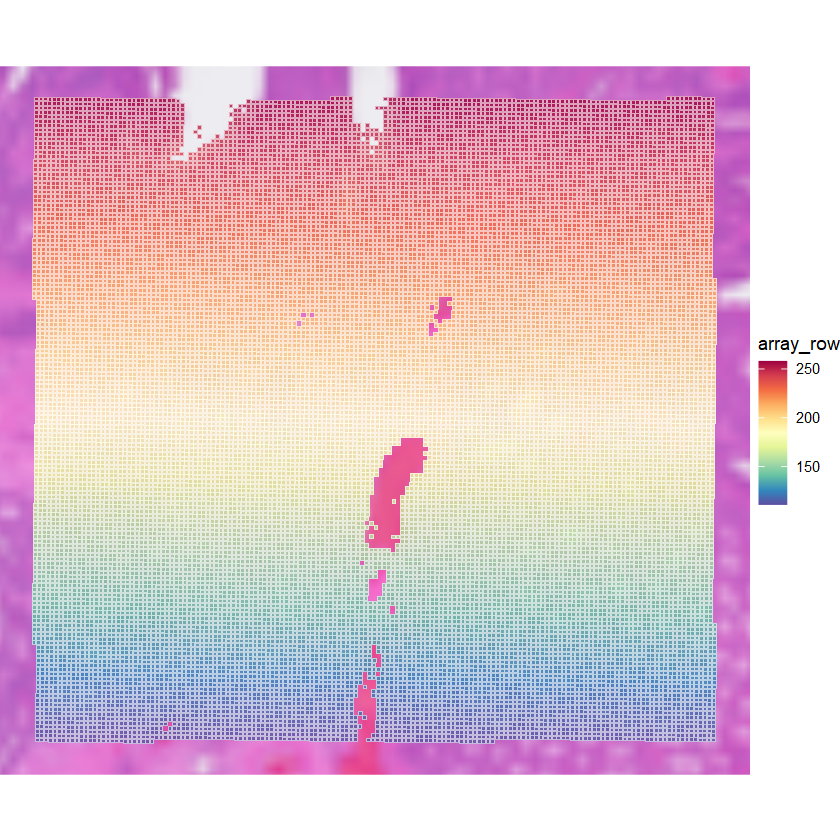

In [ ]:
# Visually verify the filter by plotting the subsetted object
suppressWarnings({
  plotVisium(
    spe[, keep_bins], 
    annotate = "array_row", 
    zoom = TRUE, 
    point_shape = 22)})

We see that our filter literally punched holes into the gradient grid. These missing bins map perfectly to the structural voids and tissue tears.

Filtering on the library size (total UMIs) effectively removes these obvious "empty" bins that Space Ranger missed. Let's apply this basic cleanup to our object now. Keep this phenomenon in mind, because we will perform much more rigorous Quality Control (QC) filtering in the next notebooks.

In [27]:
# Permanently apply this basic cleanup to our SpatialExperiment object
spe <- spe[, keep_bins]

In [28]:
# Verify the final dimensions (should be 21,966 bins)
dim(spe)

[1] 18085 21966

### Saving the object

We are now ready to save our lightly-curated `SpatialExperiment` object for the next notebooks.

Remember that our count matrix is stored as an out-of-memory `DelayedArray`. Because of this, the object **cannot** be saved using R's standard `saveRDS()` command (which would only save a fragile, temporary pointer to the data).

Instead, we must use the `saveHDF5SummarizedExperiment()` function. This safely writes the massive assay matrices as `.h5` files directly into the output directory alongside the object metadata.

In [29]:
# Define the output directory at the project root
out_dir <- "output"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# Safely save the HDF5-backed SpatialExperiment object.
# We use a descriptive prefix indicating the origin and processing state.
saveHDF5SummarizedExperiment(
  x = spe, 
  dir = out_dir, 
  prefix = "spe_visiumHD_CRC_P2_filtered_", 
  replace = TRUE, 
  chunkdim = NULL, 
  level = NULL, 
  as.sparse = NA, 
  verbose = NA)

### Clearing the environment

Before moving on to the next notebook, it is highly recommended to clear the R workspace. Because spatial transcriptomic datasets are massive, clearing the environment frees up the computer's RAM. It also ensures we are starting the next notebook from a completely clean slate, preventing any old variables from leaking into our new analysis.

*(Note: Depending on the code editor, it is also good practice to completely restart the R Kernel/Session from the menu bar before opening the next notebook).*

In [30]:
# Clear all variables from the R environment
rm(list = ls())

# Run garbage collection to aggressively free up RAM
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,9333298,498.5,16455828,878.9,13897421,742.3
Vcells,18299591,139.7,65828922,502.3,82285261,627.8
